This notebook plots AOD (timeseries and zonal/seasonal), and does the efficiiency decompoisiton into deltaAOD/inj and deltaT/AOD

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import json
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, spatial_mean, set_time_to_center_of_bounds, yearly_timeseries

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, ens_mems_CE, colours, model_colors, model_names, lat_band_dict, UKESM_ARISE_run_IDs, UKESM_ARISE_run_dict, CESM_ARISE_run_IDs

In [2]:
def get_AOD(run):
    variables = ['od_aer_0', 'od_aer_1', 'od_aer_2', 'od_aer_3', 'od_aer_dust']
    ds_list = []
    for variable in variables:
        ds = get_ds(run=run, var=variable, table='AERmon', zonal_mean=False)
        ds = ds.sel(coordinate=3) # select 550nm
        ds_list.append(ds)
    total_AOD = ds_list[0]['od_aer_0'] + ds_list[1]['od_aer_1'] + ds_list[2]['od_aer_2'] + ds_list[3]['od_aer_3'] + ds_list[4]['od_aer_dust']
    return total_AOD.to_dataset(name='AOD550')

def get_hemispheric_means(aod):
    aod_NH = aod.sel(latitude=slice(0, 91))
    aod_SH = aod.sel(latitude=slice(-91, 0))
    weights = np.cos(np.deg2rad(aod_NH['latitude']))
    aod_NH_ts = aod_NH.weighted(weights).mean(dim='latitude')
    weights = np.cos(np.deg2rad(aod_SH['latitude']))
    aod_SH_ts = aod_SH.weighted(weights).mean(dim='latitude')
    return aod_NH_ts.mean('time').AOD550.values.item(), aod_SH_ts.mean('time').AOD550.values.item()

In [3]:
### UKESM

### get background first
background_dir = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/od550aer/gn/latest/'
AOD_background_ds_UK = xr.open_mfdataset(background_dir + '*.nc').sel(time=slice('2035', '2069')).rename({'lat':'latitude', 'lon':'longitude'})

### get HiLLA
aod_HiLLA_13_UK = get_AOD('u-dm204dn587')
aod_HiLLA_15_UK = get_AOD('u-dn760')

### switch to anomaly from r1
AOD_anom_HiLLA_13_UK = (aod_HiLLA_13_UK['AOD550'] - AOD_background_ds_UK['od550aer']).to_dataset(name='AOD550_delta')
AOD_anom_HiLLA_15_UK = (aod_HiLLA_15_UK['AOD550'] - AOD_background_ds_UK['od550aer']).to_dataset(name='AOD550_delta')


### CESM
CESM_AOD_var = 'AODVIS'
CESM_AOD_table = 'AOD550_FullAtmos'

### NB - it doesn't make much difference changing between AODVIS and AODVISdn, since we have little aod in polar winter anyway


### get background first
background_dir = '/badc/cmip6/data/CMIP6/ScenarioMIP/NCAR/CESM2-WACCM/ssp245/r1i1p1f1/AERmon/od550aer/gn/latest/'
AOD_background_ds_CE = xr.open_mfdataset(background_dir + '*.nc').sel(time=slice('2035', '2069')).rename({'lat':'latitude', 'lon':'longitude'})

### get HiLLA
aod_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/{t}/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.{v}.203501-206912.nc'.format(t=CESM_AOD_table, v=CESM_AOD_var)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069')).load()
aod_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/{t}/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.{v}.203501-206912.nc'.format(t=CESM_AOD_table, v=CESM_AOD_var)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069')).load()


### switch to anomaly from r1
AOD_anom_HiLLA_13_CE = (aod_HiLLA_13_CE[CESM_AOD_var].resample(time="1MS").mean() - AOD_background_ds_CE['od550aer'].resample(time="1MS").mean()).to_dataset(name='AOD550_delta')
AOD_anom_HiLLA_15_CE = (aod_HiLLA_15_CE[CESM_AOD_var].resample(time="1MS").mean()  - AOD_background_ds_CE['od550aer'].resample(time="1MS").mean() ).to_dataset(name='AOD550_delta')


### E3SM
E3SM_AOD_table = 'regridded/AODVIS'

### get background first
AOD_background_ds_E3 = set_time_to_center_of_bounds(xr.open_mfdataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.control.nc'.format(t=E3SM_AOD_table)), 'time_bnds').sel(time=slice('2035', '2069')).rename({'lat':'latitude', 'lon':'longitude'})

### get HiLLA
aod_HiLLA_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.01.nc'.format(t=E3SM_AOD_table)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069'))
aod_HiLLA_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.04.nc'.format(t=E3SM_AOD_table)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069'))


### switch to anomaly from r1
AOD_anom_HiLLA_13_E3 = (aod_HiLLA_13_E3[CESM_AOD_var].resample(time="1MS").mean() - AOD_background_ds_E3[CESM_AOD_var].resample(time="1MS").mean()).to_dataset(name='AOD550_delta')
AOD_anom_HiLLA_15_E3 = (aod_HiLLA_15_E3[CESM_AOD_var].resample(time="1MS").mean()  - AOD_background_ds_E3[CESM_AOD_var].resample(time="1MS").mean() ).to_dataset(name='AOD550_delta')


In [4]:
### combine aods into a dict

## combine into a dict
HiLLA_aod_data = {'UKESM':{'13km':AOD_anom_HiLLA_13_UK, '15km':AOD_anom_HiLLA_15_UK},
                  'CESM':{'13km':AOD_anom_HiLLA_13_CE, '15km':AOD_anom_HiLLA_15_CE},
                  'E3SM':{'13km':AOD_anom_HiLLA_13_E3, '15km':AOD_anom_HiLLA_15_E3}}

## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    timeseries_dicts = []
    for alt in HiLLA_altitudes:
        print(model, alt)
        data = HiLLA_aod_data[model][alt]
        timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region, var='AOD550_delta') for region in regions])))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseries_dicts)))

HiLLA_aod_timeseries_dict = dict(zip(models, timeseries_dicts_models))

UKESM 13km
UKESM 15km
CESM 13km
CESM 15km
E3SM 13km
E3SM 15km


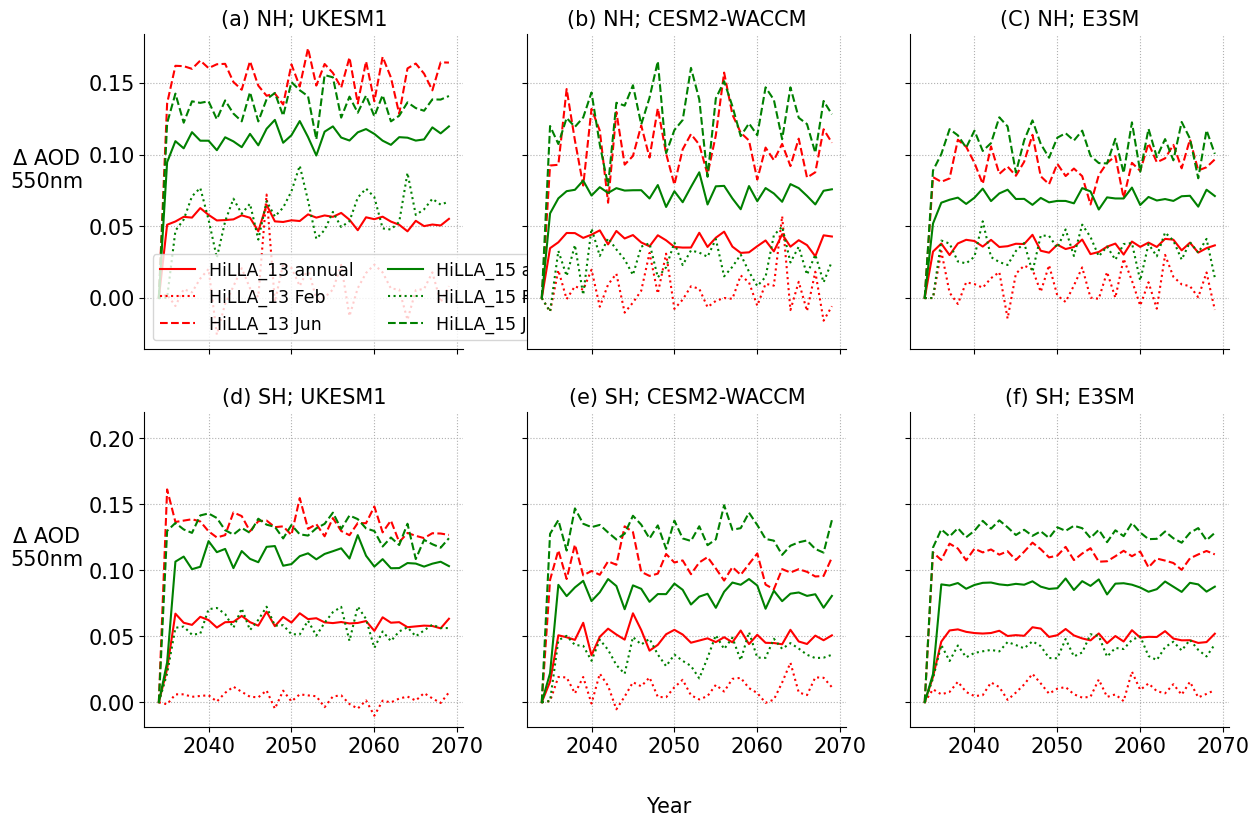

In [5]:
## now plot AOD timeseries

fig, axs = plt.subplots(2, 3, figsize=(14, 9), sharey='row', sharex=True)

run_labels = ['HiLLA_13', 'HiLLA_15']

# NH
ax = axs[0, 0]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_UK, AOD_anom_HiLLA_15_UK]:
    AOD_anom = AOD_anom.sel(latitude=slice(0, 91))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_feb = AOD_ts.where(AOD_ts.time.dt.month==2, drop=True)
    AOD_ts_jun = AOD_ts.where(AOD_ts.time.dt.month==6, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} Feb'.format(run_labels[i]), '{} Jun'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_feb, AOD_ts_jun]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize='small', ncols=2)
ax.grid(ls='dotted')

ax = axs[0, 1]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_CE, AOD_anom_HiLLA_15_CE]:
    AOD_anom = AOD_anom.sel(latitude=slice(0, 91))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_feb = AOD_ts.where(AOD_ts.time.dt.month==2, drop=True)
    AOD_ts_jun = AOD_ts.where(AOD_ts.time.dt.month==6, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} Feb'.format(run_labels[i]), '{} Jun'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_feb, AOD_ts_jun]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.legend(fontsize='small', ncols=2)
ax.grid(ls='dotted')


ax = axs[0, 2]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_E3, AOD_anom_HiLLA_15_E3]:
    AOD_anom = AOD_anom.sel(latitude=slice(0, 91))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_feb = AOD_ts.where(AOD_ts.time.dt.month==2, drop=True)
    AOD_ts_jun = AOD_ts.where(AOD_ts.time.dt.month==6, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} Feb'.format(run_labels[i]), '{} Jun'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_feb, AOD_ts_jun]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.legend(fontsize='small', ncols=2)
ax.grid(ls='dotted')


# SH
ax = axs[1, 0]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_UK, AOD_anom_HiLLA_15_UK]:
    AOD_anom = AOD_anom.sel(latitude=slice(-91, 0))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_aug = AOD_ts.where(AOD_ts.time.dt.month==8, drop=True)
    AOD_ts_dec = AOD_ts.where(AOD_ts.time.dt.month==12, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} August'.format(run_labels[i]), '{} December'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_aug, AOD_ts_dec]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
#ax.plot([], [], c='blue', ls='solid', label='Case 1 (60°-13km-MAMJ)')
#ax.axhline(np.mean(aods[-20:]), c='gray', ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.legend(fontsize='small', ncols=2)
ax.set_ylim(None, 0.22)
ax.grid(ls='dotted')

# SH
ax = axs[1, 1]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_CE, AOD_anom_HiLLA_15_CE]:
    AOD_anom = AOD_anom.sel(latitude=slice(-91, 0))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_aug = AOD_ts.where(AOD_ts.time.dt.month==8, drop=True)
    AOD_ts_dec = AOD_ts.where(AOD_ts.time.dt.month==12, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} August'.format(run_labels[i]), '{} December'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_aug, AOD_ts_dec]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
#ax.plot([], [], c='blue', ls='solid', label='Case 1 (60°-13km-MAMJ)')
#ax.axhline(np.mean(aods[-20:]), c='gray', ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.legend(fontsize='small', ncols=2)
ax.set_ylim(None, 0.22)
ax.grid(ls='dotted')


# SH
ax = axs[1, 2]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_E3, AOD_anom_HiLLA_15_E3]:
    AOD_anom = AOD_anom.sel(latitude=slice(-91, 0))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_aug = AOD_ts.where(AOD_ts.time.dt.month==8, drop=True)
    AOD_ts_dec = AOD_ts.where(AOD_ts.time.dt.month==12, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} August'.format(run_labels[i]), '{} December'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_aug, AOD_ts_dec]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
#ax.plot([], [], c='blue', ls='solid', label='Case 1 (60°-13km-MAMJ)')
#ax.axhline(np.mean(aods[-20:]), c='gray', ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(ls='dotted')



axs[0, 0].set_title('(a) NH; UKESM1', fontsize='medium')
axs[0, 1].set_title('(b) NH; CESM2-WACCM', fontsize='medium')
axs[0, 2].set_title('(C) NH; E3SM', fontsize='medium')
axs[1, 0].set_title('(d) SH; UKESM1', fontsize='medium')
axs[1, 1].set_title('(e) SH; CESM2-WACCM', fontsize='medium')
axs[1, 2].set_title('(f) SH; E3SM', fontsize='medium')
axs[0, 0].set_ylabel('\u0394 AOD\n550nm', rotation =0, labelpad=30)
axs[1, 0].set_ylabel('\u0394 AOD\n550nm', rotation =0, labelpad=30)
fig.supxlabel('Year', fontsize='medium')

plt.savefig('Figures/AOD_evolution_longersims_v2.jpg', dpi=350)

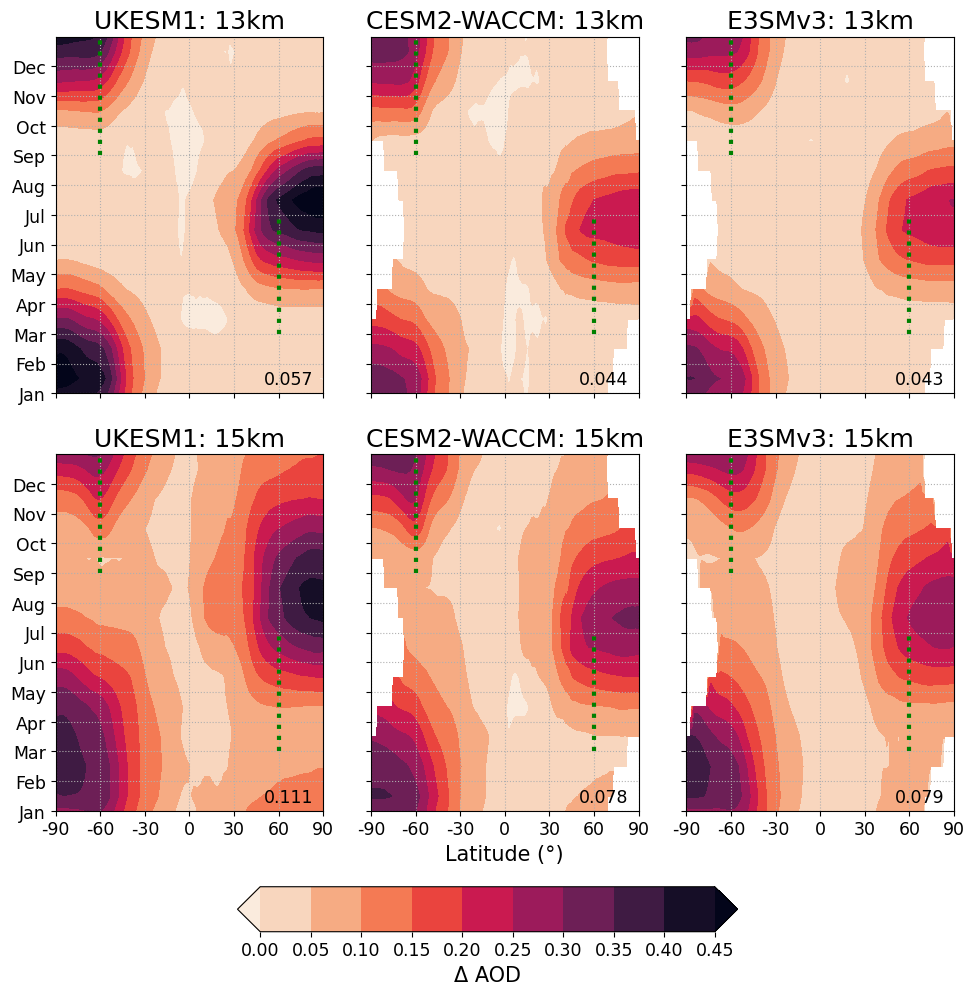

In [6]:
## Hovmoller AOD plots:

fig, axs = plt.subplots(2, 3, figsize=(10, 9),  sharex='all', sharey='all')

i=0
for alt in HiLLA_altitudes:
    for model in models:
        ax = axs.flatten()[i]
        data = HiLLA_aod_data[model][alt].sel(time=slice('2050', '2069')).mean('longitude')
        data = data.groupby(data.time.dt.month).mean()
        ## need to add a cyclic point to loop contouring between dec and jan:
        monthly_data, lats = data.AOD550_delta.values, data.latitude.values
        # Duplicate the first and last month's data and append it to the start and end
        cyclic_monthly_data = np.concatenate((monthly_data[11:12, :], monthly_data, monthly_data[0:1, :]), axis=0)
        # Create corresponding month coordinates for contourf
        cyclic_months = np.arange(-0.5, 13.5, 1)
        
        cs=ax.contourf(lats, cyclic_months,
                       cyclic_monthly_data,
                       levels = np.arange(0, 0.46, 0.05),
                       cmap=sns.color_palette("rocket_r", as_cmap=True),
                       extend='both')

        # also get global mean:
        global_mean = HiLLA_aod_timeseries_dict[model][alt]['Global'].sel(time=slice('2050', '2069'))
        global_mean = weighted_annual_resample(global_mean, 'AOD550_delta').mean('time').AOD550_delta.values.item()
        ax.text(50, 0.3, str(np.round(global_mean, 3)), fontsize='small')
        ax.set_ylim(0,12)
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.set_xticklabels(['-90', '-60', '-30', '0', '30', '60', '90'], fontsize='small')
        #ax.set_yticks([1, 3, 5, 7, 9, 11])
        ax.set_yticks([0,1,2,3,4,5,6,7,8,9,10,11])
        #ax.set_yticklabels(['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'], fontsize='small')
        ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize='small')
        #ax.set_yticklabels(['Mar', 'Jun', 'Sep'], fontsize='small')
        ax.grid(ls='dotted')
        ax.plot([60, 60], [2, 6], c='green', ls='dotted', lw=3)
        ax.plot([-60, -60], [8, 11.99999], c='green', ls='dotted', lw=3)
        ax.set_title(str(str(model_names[model]) +': ' + str(alt)))

        i=i+1
axs.flatten()[4].set_xlabel('Latitude (°)')
cbar_ax = fig.add_axes([0.25, -0.05, 0.5, 0.05])
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='horizontal', label='\u0394 AOD')
cbar.ax.tick_params(labelsize='small')
plt.tight_layout()
plt.savefig('Figures/AOD_lat_month_all.jpg', dpi=350, bbox_inches='tight')
plt.show()

# We now read in the temperature data, to produce the efficiency decomposition, following Zhang 2024

Plot: global means; (1) AOD per unit inj., (2) cooling per unit AOD, (3) cooling per unit inj.

In [7]:
## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)
arise_injs_UK, arise_injs_CE = arise_injs['UKESM'], arise_injs['CESM']

In [8]:
## u-dm204dn587 is the 35 year run for 13km 60°:
ds_HILLS_13_UK = get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))
## repeat for the 15km inj case
ds_HILLS_15_UK = get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))
# dec 2069 is still missing from the postprocessed version - TO FIX - is it?

## repeat for CESM
ds_HILLS_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HILLS_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))

## repeat for E3SM
ds_HILLS_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HILLS_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))


# now process to means:
HILLS_13_ts_yearly_UK = yearly_timeseries(ds_HILLS_13_UK, region='Global')
HILLS_15_ts_yearly_UK = yearly_timeseries(ds_HILLS_15_UK, region='Global')

HILLS_13_ts_yearly_CE= yearly_timeseries(ds_HILLS_13_CE, region='Global')
HILLS_15_ts_yearly_CE = yearly_timeseries(ds_HILLS_15_CE, region='Global')

HILLS_13_ts_yearly_E3 = yearly_timeseries(ds_HILLS_13_E3, region='Global')
HILLS_15_ts_yearly_E3 = yearly_timeseries(ds_HILLS_15_E3, region='Global')



HILLS_13_ts_arctic_yearly_UK = yearly_timeseries(ds_HILLS_13_UK, region='Arctic')
HILLS_15_ts_arctic_yearly_UK = yearly_timeseries(ds_HILLS_15_UK, region='Arctic')

HILLS_13_ts_arctic_yearly_CE = yearly_timeseries(ds_HILLS_13_CE, region='Arctic')
HILLS_15_ts_arctic_yearly_CE = yearly_timeseries(ds_HILLS_15_CE, region='Arctic')

HILLS_13_ts_arctic_yearly_E3 = yearly_timeseries(ds_HILLS_13_E3, region='Arctic')
HILLS_15_ts_arctic_yearly_E3 = yearly_timeseries(ds_HILLS_15_E3, region='Arctic')


HILLS_13_ts_tropics_yearly_UK = yearly_timeseries(ds_HILLS_13_UK, region='Tropics')
HILLS_15_ts_tropics_yearly_UK = yearly_timeseries(ds_HILLS_15_UK, region='Tropics')

HILLS_13_ts_tropics_yearly_CE = yearly_timeseries(ds_HILLS_13_CE, region='Tropics')
HILLS_15_ts_tropics_yearly_CE = yearly_timeseries(ds_HILLS_15_CE, region='Tropics')

HILLS_13_ts_tropics_yearly_E3 = yearly_timeseries(ds_HILLS_13_E3, region='Tropics')
HILLS_15_ts_tropics_yearly_E3 = yearly_timeseries(ds_HILLS_15_E3, region='Tropics')


In [10]:
path_archive

'/gws/ssde/j25b/cpom/aduffey/pp_archive_hills/'

In [11]:

# make SSP245 ensemble mean tas ds
def get_ssp245_ds(model, centre, variable, members, table='Amon', grid='gn'):
    ds_list = []
    for es in members:
        path = '/badc/cmip6/data/CMIP6/ScenarioMIP/{c}/{m}/ssp245/{e}/{t}/{v}/{g}/latest/'.format(
            c=centre, m=model, e=es, t=table,v=variable, g=grid)
        #files = os.listdir(path)
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc'))
        ds_list.append(ds)
    
    DS = xr.concat(ds_list, dim='Ensemble_member')
    return DS

def get_slice_annual_mean(DS):
    DS = DS.sel(time=slice('2015', '2069'))
    return DS.groupby('time.year').mean('time').load()

DS_ssp245_tas_UK = get_slice_annual_mean(get_ssp245_ds(model='UKESM1-0-LL', centre='MOHC', variable='tas', 
                                 members=ens_mems_arise_UK, table='Amon', grid='gn'))

DS_ssp245_tas_CE = get_slice_annual_mean(get_ssp245_ds(model='CESM2-WACCM', centre='NCAR', variable='tas', 
                                 members=ens_mems_CE, table='Amon', grid='gn'))

ds_ssp245_tas_E3 =  xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = get_slice_annual_mean(set_time_to_center_of_bounds(ds_ssp245_tas_E3, 'time_bnds'))
# SSP245 prep continued

def global_means(ds):
    # global spatial mean
    weights = np.cos(np.deg2rad(ds['y']))
    ds_ts_global = ds.weighted(weights).mean(dim='y').mean('x')
    ens1_ssp245_tas_ts_global = ds_ts_global.isel(Ensemble_member=0).tas
    ensmean_ssp245_tas_ts_global = ds_ts_global.mean(dim='Ensemble_member').tas
    ensmax_ssp245_tas_ts_global = ds_ts_global.max(dim='Ensemble_member').tas
    ensmin_ssp245_tas_ts_global = ds_ts_global.min(dim='Ensemble_member').tas

    return {'ens1':ens1_ssp245_tas_ts_global, 'mean':ensmean_ssp245_tas_ts_global, 
            'max':ensmax_ssp245_tas_ts_global, 'min':ensmin_ssp245_tas_ts_global, 
            'all':ds_ts_global.tas}

def arctic_means(ds):
    ds_arctic = ds.sel(y=slice(lat_band_dict['Arctic'][0], lat_band_dict['Arctic'][1]))
    weights = np.cos(np.deg2rad(ds_arctic['y']))
    ds_ts_arctic = ds_arctic.weighted(weights).mean(dim='y').mean('x')
    ens1_ssp245_tas_ts_arctic = ds_ts_arctic.isel(Ensemble_member=0).tas
    ensmean_ssp245_tas_ts_arctic = ds_ts_arctic.mean(dim='Ensemble_member').tas
    ensmax_ssp245_tas_ts_arctic = ds_ts_arctic.max(dim='Ensemble_member').tas
    ensmin_ssp245_tas_ts_arctic = ds_ts_arctic.min(dim='Ensemble_member').tas

    return {'ens1':ens1_ssp245_tas_ts_arctic, 'mean':ensmean_ssp245_tas_ts_arctic, 
            'max':ensmax_ssp245_tas_ts_arctic, 'min':ensmin_ssp245_tas_ts_arctic,
            'all':ds_ts_arctic.tas}

def tropics_means(ds):
    ds_tropics = ds.sel(y=slice(lat_band_dict['Tropics'][0], lat_band_dict['Tropics'][1]))
    weights = np.cos(np.deg2rad(ds_tropics['y']))
    ds_ts_tropics = ds_tropics.weighted(weights).mean(dim='y').mean('x')
    ens1_ssp245_tas_ts_tropics = ds_ts_tropics.isel(Ensemble_member=0).tas
    ensmean_ssp245_tas_ts_tropics = ds_ts_tropics.mean(dim='Ensemble_member').tas
    ensmax_ssp245_tas_ts_tropics = ds_ts_tropics.max(dim='Ensemble_member').tas
    ensmin_ssp245_tas_ts_tropics = ds_ts_tropics.min(dim='Ensemble_member').tas

    return {'ens1':ens1_ssp245_tas_ts_tropics, 'mean':ensmean_ssp245_tas_ts_tropics, 
            'max':ensmax_ssp245_tas_ts_tropics, 'min':ensmin_ssp245_tas_ts_tropics,
            'all':ds_ts_tropics.tas}
# SSP245 prep continued


global_means_tas_UK = global_means(DS_ssp245_tas_UK)
global_means_tas_CE = global_means(DS_ssp245_tas_CE)

arctic_means_tas_UK = arctic_means(DS_ssp245_tas_UK)
arctic_means_tas_CE = arctic_means(DS_ssp245_tas_CE)

tropics_means_tas_UK = tropics_means(DS_ssp245_tas_UK)
tropics_means_tas_CE = tropics_means(DS_ssp245_tas_CE)

# E3 ssp245 prep
weights = np.cos(np.deg2rad(ds_ssp245_tas_E3['latitude']))
global_mean_tas_ssp245_E3 = ds_ssp245_tas_E3.mean('longitude').weighted(weights).mean(dim='latitude').tas

ds_ssp245_tas_arctic_E3 = ds_ssp245_tas_E3.sel(latitude=slice(lat_band_dict['Arctic'][0], lat_band_dict['Arctic'][1]))
weights = np.cos(np.deg2rad(ds_ssp245_tas_arctic_E3['latitude']))
arctic_mean_tas_ssp245_E3 = ds_ssp245_tas_arctic_E3.mean('longitude').weighted(weights).mean(dim='latitude').tas

ds_ssp245_tas_tropics_E3 = ds_ssp245_tas_E3.sel(latitude=slice(lat_band_dict['Tropics'][0], lat_band_dict['Tropics'][1]))
weights = np.cos(np.deg2rad(ds_ssp245_tas_tropics_E3['latitude']))
tropics_mean_tas_ssp245_E3 = ds_ssp245_tas_tropics_E3.mean('longitude').weighted(weights).mean(dim='latitude').tas


### also get ARISE temps

ds_list_tas = []
paths_tas = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/')

for path in paths_tas:
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc'))
    ds_list_tas.append(ds)

DS_ARISE_tas_UK = get_slice_annual_mean(xr.concat(ds_list_tas, dim='Ensemble_member'))
ARISE_global_means_tas_UK = global_means(DS_ARISE_tas_UK)
ARISE_arctic_means_tas_UK = arctic_means(DS_ARISE_tas_UK)
ARISE_tropics_means_tas_UK = tropics_means(DS_ARISE_tas_UK)


## repeat for CESM
ds_list_tas = []
path = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/arise/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]

# we keep only first 5 members to align with the ssp245 runs available
# this also means there are 5 members for both models, making figures easier to interpret
files = [x for x in files if int(x.split('.')[5]) < 6] 


for file in files:
    ds = rename_cmip6(xr.open_mfdataset(path+file))
    ds['Ensemble_member'] = file.split('.')[5]
    ds_list_tas.append(ds)
DS_ARISE_tas_CE = get_slice_annual_mean(xr.concat(ds_list_tas, dim='Ensemble_member'))['TREFHT'].to_dataset(name='tas')
ARISE_global_means_tas_CE = global_means(DS_ARISE_tas_CE)
ARISE_arctic_means_tas_CE = arctic_means(DS_ARISE_tas_CE)
ARISE_tropics_means_tas_CE = tropics_means(DS_ARISE_tas_CE)

### also get the SSP245 ARISE runs for CESM
ds_list_tas = []
path = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/ssp245/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]
# we keep only first 5 members to align with the ssp245 runs available
# this also means there are 5 members for both models, making figures easier to interpret
for member in CESM_ARISE_run_IDs:
    member_files = [x for x in files if x.split('.')[6] == member] 
    paths = [path+file for file in member_files]
    ds = rename_cmip6(xr.open_mfdataset(paths))
    ds['Ensemble_member'] = member
    ds_list_tas.append(ds)
DS_SSP245_ARISE_tas_CE = get_slice_annual_mean(xr.concat(ds_list_tas, dim='Ensemble_member'))['TREFHT'].to_dataset(name='tas')
SSP245_ARISE_global_means_tas_CE = global_means(DS_SSP245_ARISE_tas_CE)
SSP245_ARISE_arctic_means_tas_CE = arctic_means(DS_SSP245_ARISE_tas_CE)
SSP245_ARISE_tropics_means_tas_CE = tropics_means(DS_SSP245_ARISE_tas_CE)

In [16]:
#################### AOD evolution ##################

### UKESM

### get ssp245 background
DS_ssp245_od550aer_UK = get_slice_annual_mean(get_ssp245_ds(model='UKESM1-0-LL', centre='MOHC', variable='od550aer', 
                     members=ens_mems_arise_UK, table='AERmon', grid='gn')).sel(year=slice('2035', '2069')).rename({'y':'latitude', 'x':'longitude'})

### get HILLS
aod_HILLS_13_UK = get_slice_annual_mean(get_AOD('u-dm204dn587'))
aod_HILLS_15_UK = get_slice_annual_mean(get_AOD('u-dn760'))

### switch to anomaly from ssp245 ens mean
AOD_anom_HILLS_13_UK = (aod_HILLS_13_UK['AOD550'] - DS_ssp245_od550aer_UK.mean('Ensemble_member')['od550aer']).to_dataset(name='AOD550_delta')
AOD_anom_HILLS_15_UK = (aod_HILLS_15_UK['AOD550'] - DS_ssp245_od550aer_UK.mean('Ensemble_member')['od550aer']).to_dataset(name='AOD550_delta')

### also get ARISE (just r1 for now)
ds_list = []
paths = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/AERmon/od550aer/gn/*/')
for path in paths:
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc'))
    ds_list.append(ds)
DS_ARISE_od550aer_UK = get_slice_annual_mean(xr.concat(ds_list, dim='Ensemble_member')).rename({'y':'latitude', 'x':'longitude'})
AOD_anom_arise_UK = (DS_ARISE_od550aer_UK['od550aer'] - DS_ssp245_od550aer_UK['od550aer']).to_dataset(name='AOD550_delta')


### plus get sAOD for ARISE, to compare:
arise_r1_dir ='/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r1i1p1f2/Emon/od550aerso/gn/v20220325/'
sAOD_arise_UK = get_slice_annual_mean(xr.open_mfdataset(arise_r1_dir + '*.nc')).rename({'lat':'latitude', 'lon':'longitude'})



### CESM
CESM_AOD_var = 'AODVIS'
CESM_AOD_table = 'AOD550_FullAtmos'

### NB - it doesn't make much difference changing between AODVIS and AODVISdn, since we have little aod in polar winter anyway


### get background first
# missing data for r4 and r5 so take the first 3 only to make background mean aod
DS_ssp245_od550aer_CE = get_slice_annual_mean(get_ssp245_ds(model='CESM2-WACCM', centre='NCAR', variable='od550aer', 
                                 members=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], table='AERmon', grid='gn')).sel(year=slice('2035', '2069')).rename({'y':'latitude', 'x':'longitude'})

### get HILLS
aod_HILLS_13_CE = get_slice_annual_mean(xr.open_dataset(path_archive+'CESM_data/{t}/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.{v}.203501-206912.nc'.format(t=CESM_AOD_table, v=CESM_AOD_var))).rename({'lat':'latitude', 'lon':'longitude'}).sel(year=slice(None, '2069'))
aod_HILLS_15_CE = get_slice_annual_mean(xr.open_dataset(path_archive+'CESM_data/{t}/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.{v}.203501-206912.nc'.format(t=CESM_AOD_table, v=CESM_AOD_var))).rename({'lat':'latitude', 'lon':'longitude'}).sel(year=slice(None, '2069'))


### switch to anomaly from ssp245 ens mean
AOD_anom_HILLS_13_CE = (aod_HILLS_13_CE[CESM_AOD_var] - DS_ssp245_od550aer_CE.mean('Ensemble_member')['od550aer']).to_dataset(name='AOD550_delta')
AOD_anom_HILLS_15_CE = (aod_HILLS_15_CE[CESM_AOD_var]  - DS_ssp245_od550aer_CE.mean('Ensemble_member')['od550aer']).to_dataset(name='AOD550_delta')

### also get ARISE 
ds_list = []
path = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/arise/{}/'.format(CESM_AOD_var)
files = os.listdir(path)
files = [x for x in files if ".nc" in x]
# we keep only first 5 members to align with the ssp245 runs available
# this also means there are 5 members for both models, making figures easier to interpret
files = [x for x in files if int(x.split('.')[5]) < 6] 
for file in files:
    ds = rename_cmip6(xr.open_mfdataset(path+file))
    ds['Ensemble_member'] = file.split('.')[5]
    ds_list.append(ds)
DS_ARISE_aod_CE = get_slice_annual_mean(xr.concat(ds_list, dim='Ensemble_member'))[CESM_AOD_var].to_dataset(name='od550aer').rename({'y':'latitude', 'x':'longitude'})
AOD_anom_arise_CE = (DS_ARISE_aod_CE['od550aer'] - DS_ssp245_od550aer_CE.mean('Ensemble_member')['od550aer']).to_dataset(name='AOD550_delta')


sAOD_var = 'AODVISstdn'
### plus get sAOD for ARISE, to compare:
arise_r1_dir = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/arise/{}/'.format(sAOD_var)
sAOD_arise_CE = get_slice_annual_mean(xr.open_mfdataset(arise_r1_dir + '*001*.nc')).rename({'lat':'latitude', 'lon':'longitude'})


E3SM_AOD_table = 'AODVIS'

### get background first
AOD_background_ds_E3 = get_slice_annual_mean(set_time_to_center_of_bounds(xr.open_mfdataset(path_archive+'E3SM_data/regridded/{t}/AODVIS.polar.mip.e3sm.control.nc'.format(t=E3SM_AOD_table)), 'time_bnds')).rename({'lat':'latitude', 'lon':'longitude'})

### get HILLS
aod_HILLS_13_E3 = get_slice_annual_mean(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/{t}/AODVIS.polar.mip.e3sm.01.nc'.format(t=E3SM_AOD_table)), 'time_bnds')).rename({'lat':'latitude', 'lon':'longitude'})
aod_HILLS_15_E3 = get_slice_annual_mean(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/{t}/AODVIS.polar.mip.e3sm.04.nc'.format(t=E3SM_AOD_table)), 'time_bnds')).rename({'lat':'latitude', 'lon':'longitude'})


### switch to anomaly from r1
AOD_anom_HILLS_13_E3 = (aod_HILLS_13_E3[CESM_AOD_var] - AOD_background_ds_E3[CESM_AOD_var]).to_dataset(name='AOD550_delta')
AOD_anom_HILLS_15_E3 = (aod_HILLS_15_E3[CESM_AOD_var] - AOD_background_ds_E3[CESM_AOD_var]).to_dataset(name='AOD550_delta')


## AOD per unit injection:
def get_scalar(ds, var):
    ds_z = ds.sel(year=slice('2050', '2069')).mean(['year', 'longitude'])
    w = np.cos(np.deg2rad(ds_z['latitude']))
    return ds_z.weighted(w).mean(dim='latitude')[var]

AOD_anom_HILLS_13_scalar_UK = get_scalar(AOD_anom_HILLS_13_UK, 'AOD550_delta')
AOD_anom_HILLS_15_scalar_UK = get_scalar(AOD_anom_HILLS_15_UK, 'AOD550_delta')
AOD_anom_arise_scalar_UK = get_scalar(AOD_anom_arise_UK, 'AOD550_delta')
sAOD_arise_scalar_UK = get_scalar(sAOD_arise_UK, 'od550aerso')

AOD_anom_HILLS_13_scalar_CE = get_scalar(AOD_anom_HILLS_13_CE, 'AOD550_delta')
AOD_anom_HILLS_15_scalar_CE = get_scalar(AOD_anom_HILLS_15_CE, 'AOD550_delta')
AOD_anom_arise_scalar_CE = get_scalar(AOD_anom_arise_CE, 'AOD550_delta')
sAOD_arise_scalar_CE = get_scalar(sAOD_arise_CE, 'AODVISstdn')

AOD_anom_HILLS_13_scalar_E3 = get_scalar(AOD_anom_HILLS_13_E3, 'AOD550_delta')
AOD_anom_HILLS_15_scalar_E3 = get_scalar(AOD_anom_HILLS_15_E3, 'AOD550_delta')
#AOD_anom_arise_scalar_E3 = get_scalar(AOD_anom_arise_CE, 'AOD550_delta')

print(AOD_anom_arise_scalar_UK, sAOD_arise_scalar_UK) # note that sAOD and delta_AOD are close but not identical for 21km inj.:
print(AOD_anom_arise_scalar_CE, sAOD_arise_scalar_CE) # note that sAOD and delta_AOD are close but not identical for 21km inj.:


###
HILLS_13_abs_temp_UK = HILLS_13_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
HILLS_15_abs_temp_UK = HILLS_15_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
ARISE_abs_temp_UK = ARISE_global_means_tas_UK['mean'].sel(year=slice('2050', '2069')).mean(['year']).item()

HILLS_13_abs_temp_CE = HILLS_13_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
HILLS_15_abs_temp_CE = HILLS_15_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
ARISE_abs_temp_CE = ARISE_global_means_tas_CE['mean'].sel(year=slice('2050', '2069')).mean(['year']).values.item()

HILLS_13_abs_temp_E3 = HILLS_13_ts_yearly_E3.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
HILLS_15_abs_temp_E3 = HILLS_15_ts_yearly_E3.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()


## get coolings:

# against ens mean
#HILLS_13_cooling_UK_scalar = (HILLS_13_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_UK['mean'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()
#HILLS_15_cooling_UK_scalar = (HILLS_15_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_UK['mean'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()

# against 1st member (from which hillas branch)
HILLS_13_cooling_UK_scalar = (HILLS_13_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_UK['ens1'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()
HILLS_15_cooling_UK_scalar = (HILLS_15_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_UK['ens1'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()

arise_cooling_UK_scalar = (ARISE_global_means_tas_UK['all'].sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_UK['mean'].sel(year=slice('2050', '2069')).mean(['year']))

# against ens mean
#HILLS_13_cooling_CE_scalar = (HILLS_13_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_CE['mean'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()
#HILLS_15_cooling_CE_scalar = (HILLS_15_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_CE['mean'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()

# against 1st member (from which hillas branch)
HILLS_13_cooling_CE_scalar = (HILLS_13_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_CE['ens1'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()
HILLS_15_cooling_CE_scalar = (HILLS_15_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']) - global_means_tas_CE['ens1'].sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()

arise_cooling_CE_scalar = (ARISE_global_means_tas_CE['all'].sel(year=slice('2050', '2069')).mean(['year']) - SSP245_ARISE_global_means_tas_CE['mean'].sel(year=slice('2050', '2069')).mean(['year']))

HILLS_13_cooling_E3_scalar = (HILLS_13_ts_yearly_E3.sel(year=slice('2050', '2069')).mean(['year']) - global_mean_tas_ssp245_E3.sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()
HILLS_15_cooling_E3_scalar = (HILLS_15_ts_yearly_E3.sel(year=slice('2050', '2069')).mean(['year']) - global_mean_tas_ssp245_E3.sel(year=slice('2050', '2069')).mean(['year'])).tas.values.item()


### also get efficiencies for arise
arise_effs_UK = [arise_cooling_UK_scalar.isel(Ensemble_member=i).item()/arise_injs_UK[UKESM_ARISE_run_dict[UKESM_ARISE_run_IDs[i]]] for i in range(5)]

arise_effs_CE = [arise_cooling_CE_scalar.isel(Ensemble_member=i).item()/arise_injs_CE[CESM_ARISE_run_IDs[i]] for i in range(5)]
print(arise_effs_UK)
print(arise_effs_CE)

### get AOD efficiencies for arise
arise_aod_effs_UK = [AOD_anom_arise_scalar_UK.isel(Ensemble_member=i).item()/arise_injs_UK[UKESM_ARISE_run_dict[UKESM_ARISE_run_IDs[i]]] for i in range(5)]
arise_aod_effs_CE = [AOD_anom_arise_scalar_CE.isel(Ensemble_member=i).item()/arise_injs_CE[CESM_ARISE_run_IDs[i]] for i in range(5)]
print(arise_aod_effs_UK)
print(arise_aod_effs_CE)

### get cooling per AOD efficiencies for arise
arise_cooling_per_aod_UK = [arise_cooling_UK_scalar.isel(Ensemble_member=i).item()/AOD_anom_arise_scalar_UK.isel(Ensemble_member=i).item() for i in range(5)]
arise_cooling_per_aod_CE = [arise_cooling_CE_scalar.isel(Ensemble_member=i).item()/AOD_anom_arise_scalar_CE.isel(Ensemble_member=i).item() for i in range(5)]
print(arise_cooling_per_aod_UK)
print(arise_cooling_per_aod_CE)

<xarray.DataArray 'AOD550_delta' (Ensemble_member: 5)> Size: 40B
array([0.20899924, 0.21791354, 0.20712505, 0.20988046, 0.21177862])
Coordinates:
    wavelength  float64 8B 550.0
Dimensions without coordinates: Ensemble_member <xarray.DataArray 'od550aerso' ()> Size: 8B
array(0.19538989)
Coordinates:
    wavelength  float64 8B 550.0
<xarray.DataArray 'AOD550_delta' (Ensemble_member: 5)> Size: 40B
array([0.13336804, 0.11022465, 0.12171799, 0.13052247, 0.12548314])
Coordinates:
  * Ensemble_member  (Ensemble_member) <U3 60B '005' '004' '003' '001' '002' <xarray.DataArray 'AODVISstdn' ()> Size: 8B
array(0.1376132)
[-0.12642776614621193, -0.10946198627628131, -0.1288287317462868, -0.12143653840790604, -0.11876735976681883]
[-0.10773690954698392, -0.10653241506732433, -0.11849807229659864, -0.12143366922599852, -0.0984842057995664]
[0.015977917103611506, 0.014683288150354998, 0.01673401544989229, 0.015563359636817575, 0.015012608308098774]
[0.015115906042330485, 0.01357221701272036, 0.01550

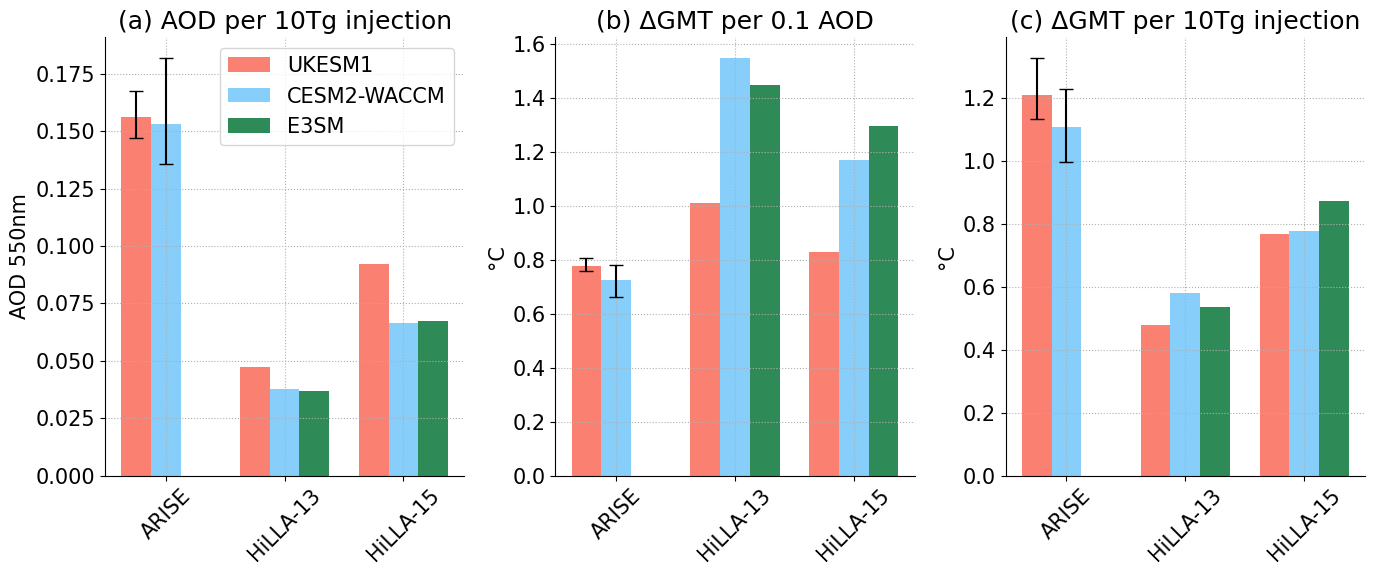

In [17]:

# Setup
fig, axs = plt.subplots(1, 3, figsize=(14, 6))

run_labels = ['ARISE', 'HiLLA-13', 'HiLLA-15']
titles = ['(a) AOD per 10Tg injection', '(b) ΔGMT per 0.1 AOD', '(c) ΔGMT per 10Tg injection']
ylabels = ['AOD 550nm', '°C', '°C']

x = np.arange(len(run_labels))  # bar positions
bar_width = 0.25  # width of each bar

# --- Plot 1: AOD per 10Tg injection ---
ax = axs[0]
UK_values = [10*np.mean(arise_aod_effs_UK),
             10*AOD_anom_HILLS_13_scalar_UK/12,
             10*AOD_anom_HILLS_15_scalar_UK/12]

CE_values = [10*np.mean(arise_aod_effs_CE),
             10*AOD_anom_HILLS_13_scalar_CE/12,
             10*AOD_anom_HILLS_15_scalar_CE/12]

E3_values = [np.nan, 
             10*AOD_anom_HILLS_13_scalar_E3/12,
             10*AOD_anom_HILLS_15_scalar_E3/12]

ax.bar(x - bar_width, UK_values, width=bar_width, label='UKESM1', color=model_colors['UKESM'],
       yerr=[[10*np.abs(np.min(arise_aod_effs_UK) - np.mean(arise_aod_effs_UK)), np.nan, np.nan], 
             [10*np.abs(np.max(arise_aod_effs_UK) - np.mean(arise_aod_effs_UK)), np.nan, np.nan]],
       error_kw={'capsize':5})
ax.bar(x, CE_values, width=bar_width, label='CESM2-WACCM', color=model_colors['CESM'],
       yerr=[[10*np.abs(np.min(arise_aod_effs_CE) - np.mean(arise_aod_effs_CE)), np.nan, np.nan], 
             [10*np.abs(np.max(arise_aod_effs_CE) - np.mean(arise_aod_effs_CE)), np.nan, np.nan]],
       error_kw={'capsize':5})
ax.bar(x + bar_width, E3_values, width=bar_width, label='E3SM', color=model_colors['E3SM'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(ls='dotted')
ax.set_title(titles[0])
ax.set_ylabel(ylabels[0])
ax.set_xticks(x)
ax.set_xticklabels(run_labels, rotation=45)
ax.legend()

# --- Plot 2: Cooling per 0.1 AOD ---
ax = axs[1]
UK_values = [-0.1*np.mean(arise_cooling_per_aod_UK),
             -0.1*HILLS_13_cooling_UK_scalar/AOD_anom_HILLS_13_scalar_UK,
             -0.1*HILLS_15_cooling_UK_scalar/AOD_anom_HILLS_15_scalar_UK]

CE_values = [-0.1*np.mean(arise_cooling_per_aod_CE),
             -0.1*HILLS_13_cooling_CE_scalar/AOD_anom_HILLS_13_scalar_CE,
             -0.1*HILLS_15_cooling_CE_scalar/AOD_anom_HILLS_15_scalar_CE]

E3_values = [np.nan, 
             -0.1*HILLS_13_cooling_E3_scalar/AOD_anom_HILLS_13_scalar_E3,
             -0.1*HILLS_15_cooling_E3_scalar/AOD_anom_HILLS_15_scalar_E3]

ax.bar(x - bar_width, UK_values, width=bar_width, label='UKESM1', color=model_colors['UKESM'],
      yerr=[[0.1*np.abs(np.min(arise_cooling_per_aod_UK) - np.mean(arise_cooling_per_aod_UK)), np.nan, np.nan], 
             [0.1*np.abs(np.max(arise_cooling_per_aod_UK) - np.mean(arise_cooling_per_aod_UK)), np.nan, np.nan]],
       error_kw={'capsize':5})
ax.bar(x, CE_values, width=bar_width, label='CESM2-WACCM', color=model_colors['CESM'],
       yerr=[[0.1*np.abs(np.min(arise_cooling_per_aod_CE) - np.mean(arise_cooling_per_aod_CE)), np.nan, np.nan], 
             [0.1*np.abs(np.max(arise_cooling_per_aod_CE) - np.mean(arise_cooling_per_aod_CE)), np.nan, np.nan]],
       error_kw={'capsize':5})
ax.bar(x + bar_width, E3_values, width=bar_width, label='E3SM', color=model_colors['E3SM'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(ls='dotted')
ax.set_title(titles[1])
ax.set_ylabel(ylabels[1])
ax.set_xticks(x)
ax.set_xticklabels(run_labels, rotation=45)
#ax.legend()

# --- Plot 3: Cooling per 10Tg injection ---
ax = axs[2]
UK_values = [-10*np.mean(arise_effs_UK),
             -10*HILLS_13_cooling_UK_scalar/12,
             -10*HILLS_15_cooling_UK_scalar/12]

CE_values = [-10*np.mean(arise_effs_CE),
             -10*HILLS_13_cooling_CE_scalar/12,
             -10*HILLS_15_cooling_CE_scalar/12]

E3_values = [np.nan, 
             -10*HILLS_13_cooling_E3_scalar/12,
             -10*HILLS_15_cooling_E3_scalar/12]

ax.bar(x - bar_width, UK_values, width=bar_width, label='UKESM1', color=model_colors['UKESM'],
       yerr=[[10*np.abs(np.min(arise_effs_UK) - np.mean(arise_effs_UK)), np.nan, np.nan], 
             [10*np.abs(np.max(arise_effs_UK) - np.mean(arise_effs_UK)), np.nan, np.nan]],
       error_kw={'capsize':5})
ax.bar(x, CE_values, width=bar_width, label='CESM2-WACCM', color=model_colors['CESM'],
       yerr=[[10*np.abs(np.min(arise_effs_CE) - np.mean(arise_effs_CE)), np.nan, np.nan], 
             [10*np.abs(np.max(arise_effs_CE) - np.mean(arise_effs_CE)), np.nan, np.nan]],
       error_kw={'capsize':5})
ax.bar(x + bar_width, E3_values, width=bar_width, label='E3SM', color=model_colors['E3SM'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(ls='dotted')
ax.set_title(titles[2])
ax.set_ylabel(ylabels[2])
ax.set_xticks(x)
ax.set_xticklabels(run_labels, rotation=45)
#ax.legend()

plt.tight_layout()
plt.savefig('Figures/Efficiencies_grouped_v3.jpg', dpi=300)
